In [1]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
import itertools
import glob
import os
from sklearn.preprocessing import MinMaxScaler

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.interpolate import interp1d

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Color Palettes
palette1 = itertools.cycle(sns.color_palette(palette='Set1'))
palette2 = itertools.cycle(sns.color_palette(palette='Set2'))

In [2]:
directory_name = "D:\\2 inch Pump CSV Files"

In [3]:
os.chdir(directory_name)

In [4]:
os.getcwd()

'D:\\2 inch Pump CSV Files'

In [5]:
# current directory csv files
csvs = [x for x in os.listdir(directory_name) if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [6]:
dic_csv.keys()

dict_keys(['T01_20_10C_Perform_ratio_2050Hrs', 'T02_P3_20_2C_Perform_ratio', 'T03_20_Perform_ratio_370Hrs', 'T04_20_2C_Perform_ratio_300Hrs', 'T05_20_4C_Perform_ratio_120Hrs', 'T06_20_1C_Perform_ratio_370Hrs', 'T07_20_4C_Perform_ratio_47Hrs'])

In [13]:
dic_csv['T01_20_10C_Perform_ratio_2050Hrs']

,Diaphragm_life,Efficiency,max_point,T01_Perf_%_cal_600,T01_Perf_%_cal_540,T01_Perf_%_cal_480,T01_Perf_%_cal_420,T01_Perf_%_cal_360,T01_Perf_%_cal_300
0,0.000000,531.914860,NaN,-11.347523,-1.497248,10.815596,26.646395,47.754128,77.304953
1,183.333333,559.708888,559.708888,-6.715185,3.649794,16.606018,33.264021,55.474691,86.569629
2,366.666667,554.302811,NaN,-7.616198,2.648669,15.479752,31.976860,53.973003,84.767604
3,550.000000,541.552293,NaN,-9.741284,0.287462,12.823394,28.941022,50.431193,80.517431
4,733.333333,525.020900,NaN,-12.496517,-2.773908,9.379354,25.004976,45.839139,75.006966
5,916.666667,531.256784,NaN,-11.457203,-1.619114,10.678497,26.489711,47.571329,77.085595
6,1100.000000,537.544447,NaN,-10.409259,-0.454732,11.988427,27.986773,49.317902,79.181482
7,1283.333333,544.505775,544.505775,-9.249038,0.834403,13.438703,29.644232,51.251604,81.501925
8,1466.666667,537.353188,NaN,-10.441135,-0.490150,11.948581,27.941235,49.264774,79.117729
9,1650.000000,522.637676,NaN,-12.893721,-3.215245,8.882849,24.437542,45.177132,74.212559


In [19]:
# Specify the column you want to extract
column_x = [0]
column_y = [3]
x_data = []
y_data = []


In [20]:
for key, df in dic_csv.items():
    x_data.append(df.iloc[:,column_x])
    y_data.append(df.iloc[:,column_y])

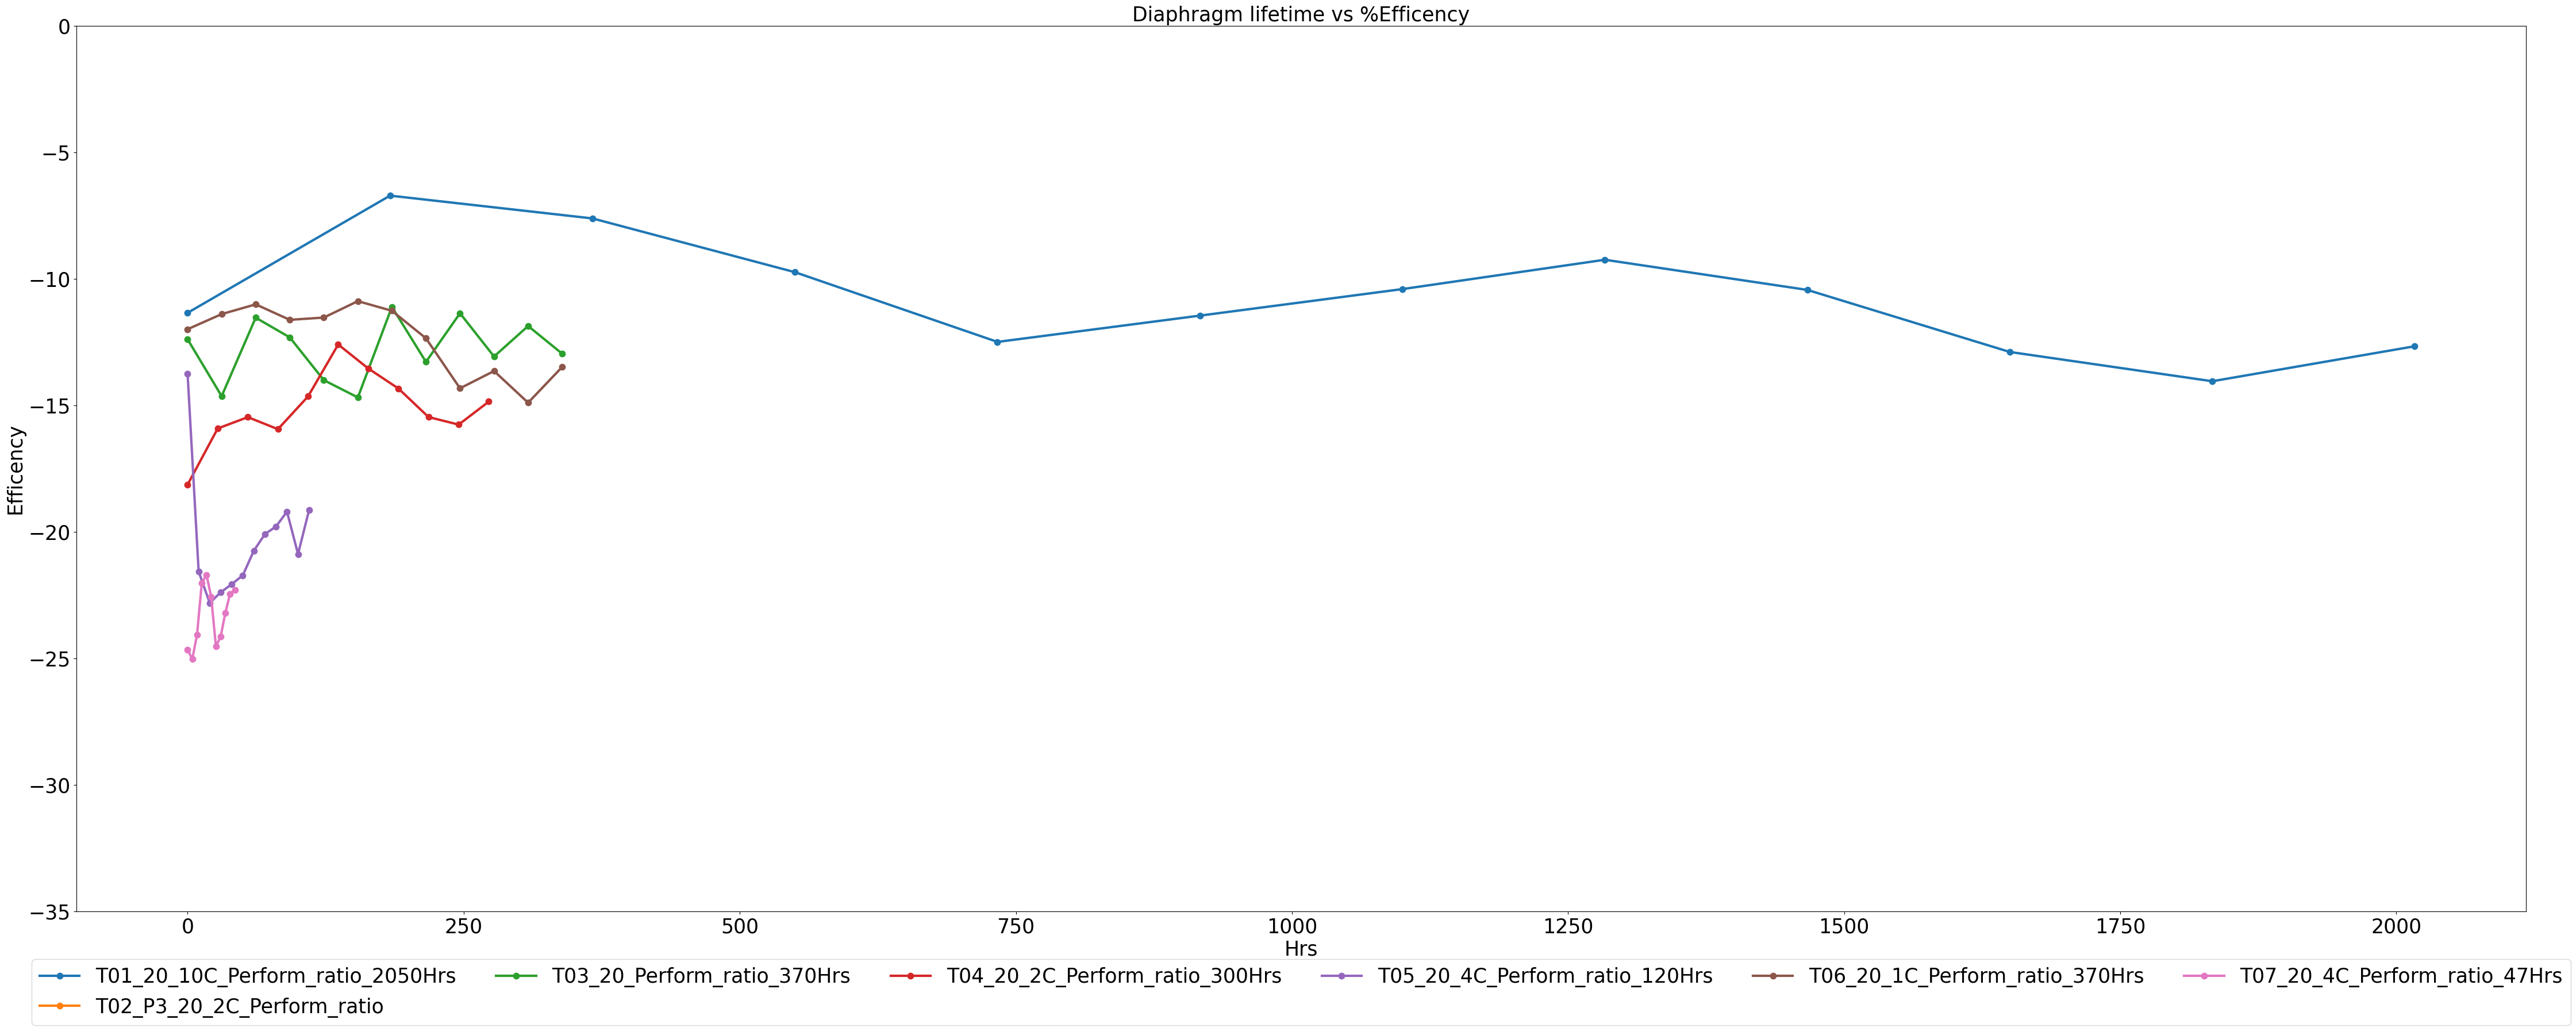

In [31]:
fig1 = plt.figure(figsize=(55,20))

SMALL_SIZE = 25

for i,j,in zip(x_data,y_data):
    plt.plot(i, j, marker='.',linewidth=3, markersize=15)

plt.legend(dic_csv.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=6)       
#plt.xlim(0,150)
plt.ylim(-35,0)
plt.xlabel('Hrs')
plt.ylabel('Efficency')
plt.title("Diaphragm lifetime vs %Efficency")


plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.show()
    

In [67]:
# Specify the column you want to extract
column_indices = [2]

# Create a new DataFrame to store the specified column from each DataFrame
result_df = pd.DataFrame()

# Loop through each key and DataFrame in dic_csv
for key, df in dic_csv.items():
    for idx in column_indices:
        # Extract the specified column by index and add it to the result DataFrame
        #column_name = df.columns[idx]
        result_df[key] = df.iloc[:, idx]


In [68]:
result_df

,T08_20_R_2C_at top and Lgood_Perform_ratio,T09_20_L_2C_at top and Rgood_Perform_ratio,T10_20_L_3C_Rgood_Perform_ratio,T11_20_R_3C_Lgood_Perform_ratio,T12_20_R_4C_Lgood_Perform_ratio,T13_20_L_4C_Rgood_Perform_ratio,T14_20_L_4C_Rgood_Perform_ratio,T15_20_L_4C_Rgood_Perform_ratio,T16_20_R_4C_L2C_Perform_ratio
0,-27.511078,-25.222171,-24.909683,-26.381050,-28.339201,-26.703357,-23.886475,-25.008226,-25.141596
1,-26.077668,-24.718921,-26.033343,-26.384922,-27.673519,-27.598865,-23.326046,-25.194182,-23.434446
2,-25.776292,-24.563028,-26.078116,-25.771789,-27.909940,-27.341680,-24.000185,-25.274962,-23.805222
3,-25.862112,-25.077720,-26.036713,-25.520436,-27.933564,-27.316349,-24.408997,-25.158571,-24.246830
4,-26.416730,-24.799703,-25.909187,-25.613460,-27.226274,-26.708128,-24.623550,-25.137127,-24.395709
5,-25.929132,-24.719641,-25.459635,-25.033861,-26.146300,-27.222519,-23.620953,-24.938596,-24.477701
6,-25.618778,-25.423922,-25.337662,-25.894452,-26.976602,-26.773051,-24.479983,-24.782120,-19.680103
7,-25.159542,-24.869813,-25.122146,-25.820498,-26.649677,-26.251220,-24.063134,-24.595607,NaN
8,-25.501569,-25.011013,-25.258419,-25.624217,-27.315707,-25.762785,-24.376121,-24.639195,NaN
9,-25.075475,-25.383961,-25.383852,-26.315542,-27.109143,-25.721575,-24.618117,-23.749378,NaN


In [69]:
len(result_df)

14

In [70]:
marker_list = ['*','H','d','^','D','>','1','s','P']

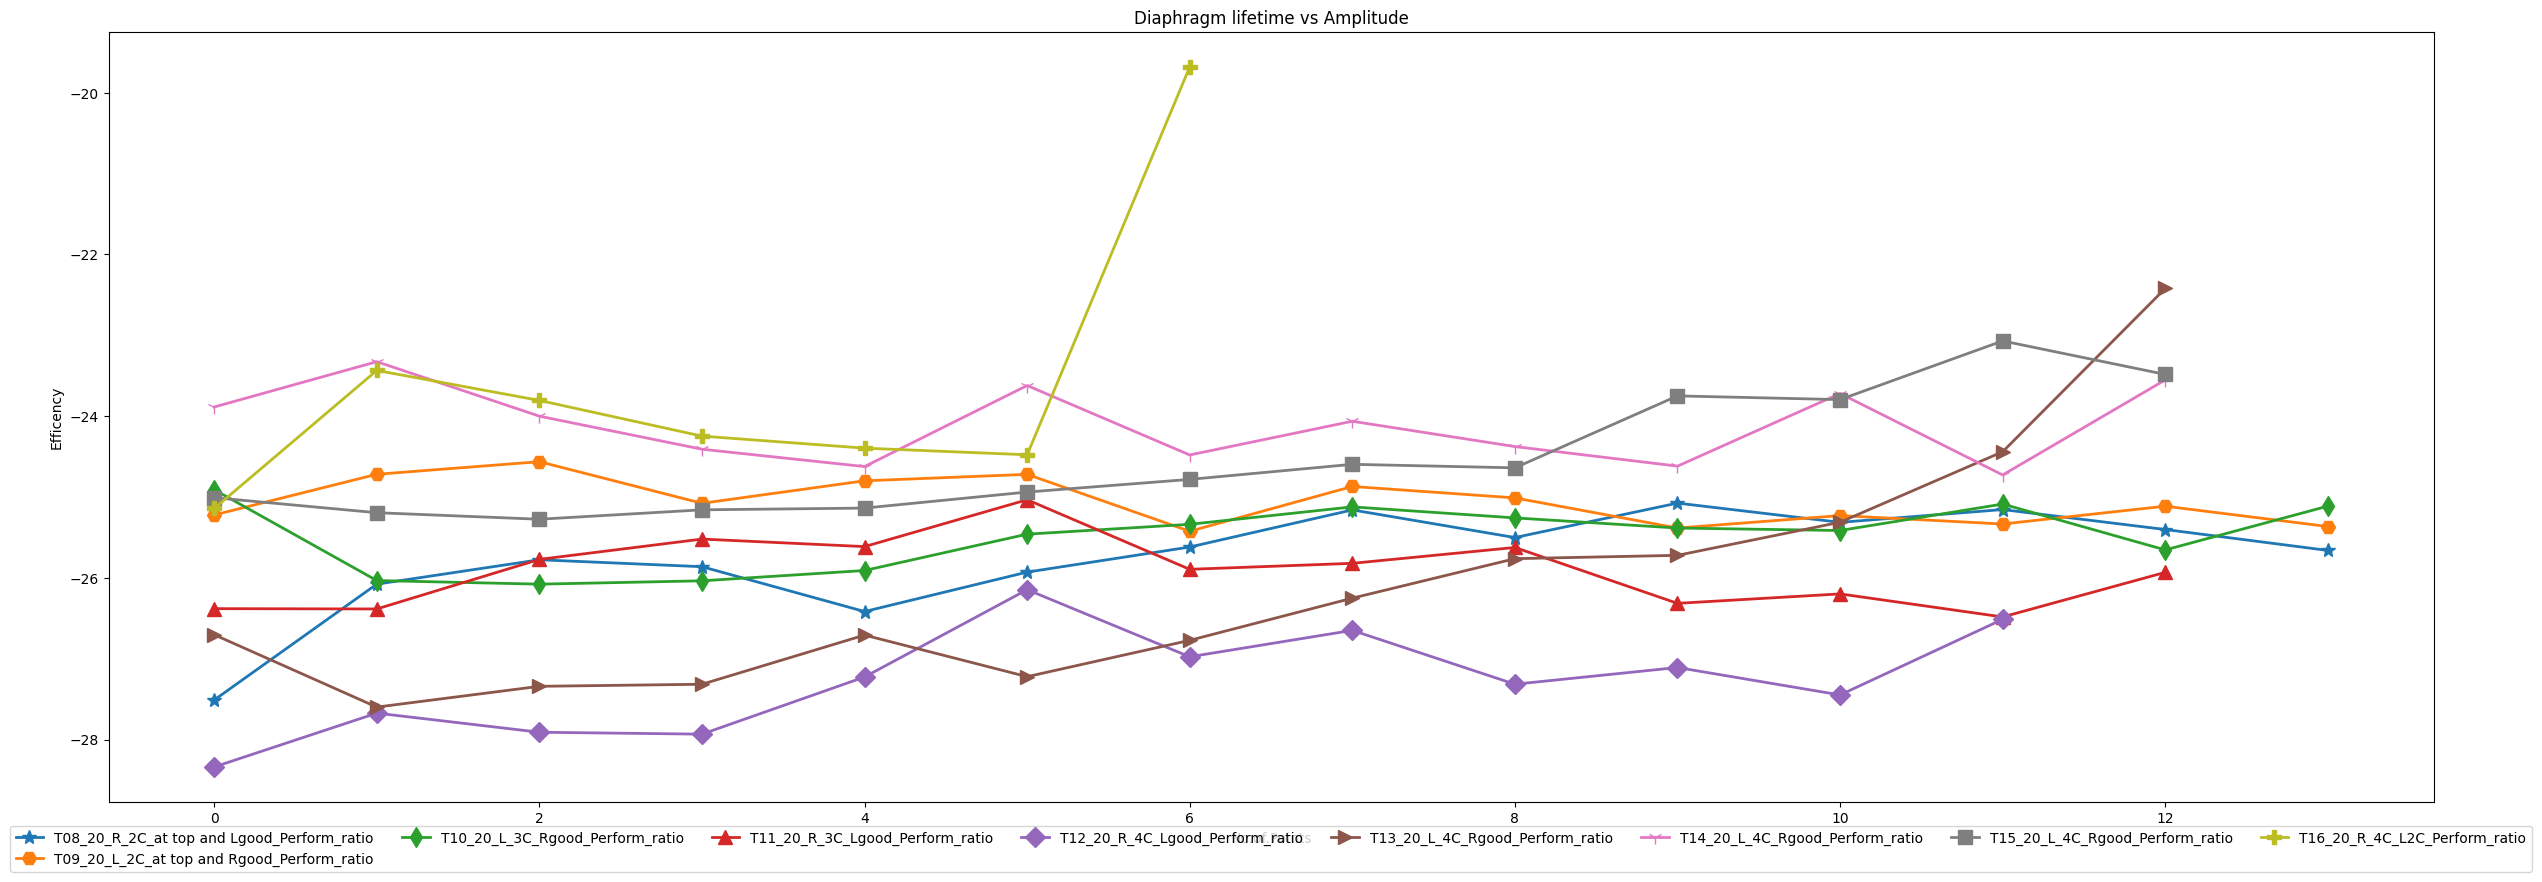

In [74]:
plt.figure(figsize=(30,10))
for k, i in enumerate(result_df.columns):
    plt.plot(result_df[i], marker=marker_list[k], label = k,
     linewidth=2, markersize=10)

#plt.xlim(0,400)
#plt.ylim(0,8000000)
plt.xlabel('No.of.Points')
plt.ylabel('Efficency')
#plt.grid()
plt.title('Diaphragm lifetime vs Amplitude')
plt.legend(result_df, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=8)